# DQN Atari Pong — Experiment Notebook

**Course:** Artificial Intelligence — Project 3  
**Topic:** Deep Reinforcement Learning on Atari Pong  
**Algorithm:** Deep Q-Network (DQN) with ablations  

## References
- Mnih et al. (2015). *Human-level control through deep reinforcement learning*. Nature.
- Joachimiak, K. (2023). *Learning to play Pong with PyTorch & Tianshou*. Medium.
- Tianshou library: Weng et al. (2022). https://github.com/thu-ml/tianshou
- Stable-Baselines3 Atari wrappers: Raffin et al. (2021).

## Experiments Overview
| # | Experiment | Variable | Values |
|---|-----------|----------|--------|
| 1 | Replay Buffer Size | `buffer_size` | 10k, 50k, 100k |
| 2 | DQN vs Double DQN | `is_double` | False, True |
| 3 | Target Network Update Frequency | `target_update_freq` | 100, 500, 1000 steps |
| 4 | ε-decay Schedule | `eps_schedule` | linear, exponential, constant |

## 1. Setup — Imports

In [ ]:
!pip install "tianshou==0.5.1" "gymnasium[atari]" "ale-py" "autorom[accept-rom-license]" "stable-baselines3[extra]" tensorboard -q
!python -m autorom --accept-license 2>/dev/null

import ale_py
import gymnasium as gym
gym.register_envs(ale_py)

import torch
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"PyTorch: {torch.__version__}")
env = gym.make("PongNoFrameskip-v4")
print("✓ All packages installed and Pong works!")
env.close()

In [2]:
import os
import time
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import deque

import torch
import torch.nn as nn
import gymnasium as gym
import ale_py
gym.register_envs(ale_py)

from stable_baselines3.common.atari_wrappers import FireResetEnv
from tianshou.env import ShmemVectorEnv, DummyVectorEnv
from tianshou.data import Collector, VectorReplayBuffer, PrioritizedVectorReplayBuffer
from tianshou.policy import DQNPolicy
from tianshou.trainer import offpolicy_trainer
from tianshou.utils import TensorboardLogger
from torch.utils.tensorboard import SummaryWriter
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Gymnasium: {gym.__version__}")
print("All imports successful!")


Device: cpu
PyTorch: 2.11.0+cpu
Gymnasium: 1.2.3
All imports successful!


c:\Users\janas\AppData\Local\Programs\Python\Python313\Lib\site-packages\wandb\analytics\sentry.py:90: SentryHubDeprecationWarning: `sentry_sdk.Hub` is deprecated and will be removed in a future major release. Please consult our 1.x to 2.x migration guide for details on how to migrate `Hub` usage to the new API: https://docs.sentry.io/platforms/python/migration/1.x-to-2.x
  self.hub = sentry_sdk.Hub(client)


## 2. Setup — Configuration

In [ ]:
# ── Environment ──────────────────────────────────────────────
ENV_NAME     = "PongNoFrameskip-v4"
SEED         = 42
NUM_STACK    = 4          # number of frames to stack

# ── Shared hyperparameters (fixed across all experiments) ────
GAMMA        = 0.99
BATCH_SIZE   = 64
LEARNING_RATE = 1e-4
N_TRAIN_ENVS = 4
N_TEST_ENVS  = 1
STEP_PER_COLLECT  = 10
UPDATE_PER_STEP   = 0.1
EPISODE_PER_TEST  = 10

# ── Training length ──────────────────────────────────────────
# Set QUICK_MODE = True to run short test runs (~10 min each).
# Set QUICK_MODE = False for full training (~2-4 h each).
QUICK_MODE   = False

if QUICK_MODE:
    MAX_EPOCH      = 5
    STEP_PER_EPOCH = 20_000   # 100k total steps per run
    print("⚡ QUICK_MODE: short runs for testing. Set QUICK_MODE=False for full training.")
else:
    MAX_EPOCH      = 20
    STEP_PER_EPOCH = 100_000  # 2M total steps per run
    print("🔥 Full training mode.")

# ── Baseline defaults (used in all experiments unless varied) ─
DEFAULT_BUFFER_SIZE      = 100_000
DEFAULT_TARGET_FREQ      = 500
DEFAULT_EPS_START        = 1.0
DEFAULT_EPS_FINAL        = 0.01
DEFAULT_EPS_DECAY        = 1_000_000
DEFAULT_EPS_SCHEDULE     = "linear"
DEFAULT_IS_DOUBLE        = False

# ── Output directories ────────────────────────────────────────
RESULTS_DIR = "results"
LOGS_DIR    = "tb_logs"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)

⚡ QUICK_MODE: short runs for testing. Set QUICK_MODE=False for full training.


## 3. Setup — Environment Wrappers
Based on Joachimiak (2023) and the original DQN paper (Mnih et al., 2015).
The preprocessing pipeline converts raw Atari frames into a format suitable for the CNN:
1. **FireResetEnv** — sends FIRE action at episode start to begin the game  
2. **AtariPreprocessing** — grayscale, resize to 84×84, frame-skip=4  
3. **FrameStack** — stacks last 4 frames to give the agent temporal information

In [4]:
def _parse_reset_result(reset_result):
    contains_info = (
        isinstance(reset_result, tuple)
        and len(reset_result) == 2
        and isinstance(reset_result[1], dict)
    )
    if contains_info:
        return reset_result[0], reset_result[1], contains_info
    return reset_result, {}, contains_info


class FrameStack(gym.Wrapper):
    """
    Custom FrameStack compatible with Tianshou buffers.
    Source: Joachimiak (2023) — fixes incompatibility with gym's built-in FrameStack.
    """
    def __init__(self, env, n_frames):
        super().__init__(env)
        self.n_frames = n_frames
        self.frames = deque([], maxlen=n_frames)
        shape = (n_frames, *env.observation_space.shape)
        self.observation_space = gym.spaces.Box(
            low=np.min(env.observation_space.low),
            high=np.max(env.observation_space.high),
            shape=shape,
            dtype=env.observation_space.dtype,
        )

    def reset(self, **kwargs):
        obs, info, return_info = _parse_reset_result(self.env.reset(**kwargs))
        for _ in range(self.n_frames):
            self.frames.append(obs)
        return (self._get_ob(), info) if return_info else self._get_ob()

    def step(self, action):
        step_result = self.env.step(action)
        if len(step_result) == 4:
            obs, reward, done, info = step_result
            new_step_api = False
        else:
            obs, reward, term, trunc, info = step_result
            new_step_api = True
        self.frames.append(obs)
        if new_step_api:
            return self._get_ob(), reward, term, trunc, info
        return self._get_ob(), reward, done, info

    def _get_ob(self):
        return np.stack(self.frames, axis=0)


def make_env(env_name=ENV_NAME, render_mode=None):
    """Build one preprocessed Pong environment."""
    env = gym.make(env_name, render_mode=render_mode)
    env = FireResetEnv(env)
    env = gym.wrappers.AtariPreprocessing(
        env=env,
        noop_max=0,
        frame_skip=4,
        screen_size=84,
        grayscale_obs=True,
        scale_obs=True,
    )
    env = FrameStack(env, n_frames=NUM_STACK)
    return env


# Sanity check
_tmp = make_env()
print(f"Observation shape : {_tmp.observation_space.shape}")
print(f"Number of actions : {_tmp.action_space.n}")
print(f"Action meanings   : {_tmp.unwrapped.get_action_meanings()}")
_tmp.close()

Observation shape : (4, 84, 84)
Number of actions : 6
Action meanings   : ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']


## 4. Setup — Network Architecture
Standard DQN convolutional network from Mnih et al. (2015):
- 3 convolutional layers to process the 84×84×4 stacked frames  
- 2 fully-connected layers to map features to Q-values  
- One output neuron per action (6 actions in Pong)

In [5]:
class DQN(nn.Module):
    """
    Convolutional Deep Q-Network.
    Architecture: Mnih et al. (2015), adapted for Tianshou by Joachimiak (2023).

    Input : (batch, 4, 84, 84) — 4 stacked grayscale frames
    Output: (batch, n_actions) — Q-value estimate for each action
    """
    def __init__(self, input_shape, n_actions):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )
        with torch.no_grad():
            conv_out = int(np.prod(
                self.conv(torch.zeros(1, *input_shape)).shape
            ))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv_out, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x, state=None, **kwargs):
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32)
        x = x.to(DEVICE)
        return self.fc(self.conv(x)), state


# Print architecture info
_env = make_env()
obs_shape = _env.observation_space.shape
n_actions = _env.action_space.n
_env.close()

_net = DQN(obs_shape, n_actions)
total_params = sum(p.numel() for p in _net.parameters())
print(f"Input shape        : {obs_shape}")
print(f"Number of actions  : {n_actions}")
print(f"Total parameters   : {total_params:,}")
del _net

Input shape        : (4, 84, 84)
Number of actions  : 6
Total parameters   : 1,687,206


## 5. Setup — Helper Functions

In [9]:
def make_envs(n_train=N_TRAIN_ENVS, n_test=N_TEST_ENVS):
    """Create vectorized environments."""
    train_envs = DummyVectorEnv([lambda: make_env() for _ in range(n_train)])
    test_envs  = DummyVectorEnv([lambda: make_env() for _ in range(n_test)])
    train_envs.seed(SEED)
    test_envs.seed(SEED + 100)
    return train_envs, test_envs


def run_experiment(
    exp_name,
    buffer_size      = DEFAULT_BUFFER_SIZE,
    target_freq      = DEFAULT_TARGET_FREQ,
    eps_start        = DEFAULT_EPS_START,
    eps_final        = DEFAULT_EPS_FINAL,
    eps_decay        = DEFAULT_EPS_DECAY,
    eps_schedule     = DEFAULT_EPS_SCHEDULE,
    is_double        = DEFAULT_IS_DOUBLE,
):
    """
    Run one DQN experiment. Results are cached to disk so re-running
    the cell just loads the saved results without re-training.

    Returns a dict with config, metrics, and log_path for plotting.
    """
    results_path = os.path.join(RESULTS_DIR, f"{exp_name}.json")
    if os.path.exists(results_path):
        print(f"[{exp_name}] ✓ Loaded cached results.")
        with open(results_path) as f:
            return json.load(f)

    print(f"\n{'='*55}")
    print(f" Experiment : {exp_name}")
    print(f" Buffer     : {buffer_size:,}")
    print(f" TargetFreq : {target_freq}")
    print(f" ε-schedule : {eps_schedule}  ({eps_start}→{eps_final})")
    print(f" Double DQN : {is_double}")
    print(f"{'='*55}\n")

    t0 = time.time()

    train_envs, test_envs = make_envs()
    net   = DQN(train_envs.observation_space[0].shape,
                train_envs.action_space[0].n).to(DEVICE)
    optim = torch.optim.Adam(net.parameters(), lr=LEARNING_RATE)

    policy = DQNPolicy(
        model              = net,
        optim              = optim,
        discount_factor    = GAMMA,
        estimation_step    = 1,
        target_update_freq = target_freq,
        is_double          = is_double,
    ).to(DEVICE)

    buffer = VectorReplayBuffer(
        total_size       = buffer_size,
        buffer_num       = len(train_envs),
        stack_num        = NUM_STACK,
        ignore_obs_next  = True,
        save_only_last_obs = True,
    )

    train_col = Collector(policy, train_envs, buffer, exploration_noise=True)
    test_col  = Collector(policy, test_envs)

    log_path = os.path.join(LOGS_DIR, exp_name)
    os.makedirs(log_path, exist_ok=True)
    writer = SummaryWriter(log_path)
    logger = TensorboardLogger(writer)

    def train_fn(epoch, env_step):
        if eps_schedule == "linear":
            eps = max(eps_final,
                      eps_start - env_step / eps_decay * (eps_start - eps_final))
        elif eps_schedule == "exponential":
            eps = max(eps_final,
                      eps_start * (eps_final / eps_start) ** (env_step / eps_decay))
        else:  # constant — always use eps_final
            eps = eps_final
        policy.set_eps(eps)

    def test_fn(epoch, env_step):
        policy.set_eps(0.0)

    def save_best_fn(pol):
        path = os.path.join(log_path, "best_policy.pth")
        torch.save(pol.state_dict(), path)

    result = offpolicy_trainer(
        policy           = policy,
        train_collector  = train_col,
        test_collector   = test_col,
        max_epoch        = MAX_EPOCH,
        step_per_epoch   = STEP_PER_EPOCH,
        step_per_collect = STEP_PER_COLLECT,
        update_per_step  = UPDATE_PER_STEP,
        episode_per_test = EPISODE_PER_TEST,
        batch_size       = BATCH_SIZE,
        train_fn         = train_fn,
        test_fn          = test_fn,
        save_best_fn     = save_best_fn,
        logger           = logger,
        verbose          = True,
    )

    elapsed = time.time() - t0
    best_rew = float(result.get("best_reward", result.get("rew", -21)))

    output = {
        "exp_name" : exp_name,
        "config"   : {
            "buffer_size"  : buffer_size,
            "target_freq"  : target_freq,
            "eps_schedule" : eps_schedule,
            "eps_start"    : eps_start,
            "eps_final"    : eps_final,
            "eps_decay"    : eps_decay,
            "is_double"    : is_double,
        },
        "metrics"  : {
            "best_reward"      : best_rew,
            "training_time_min": round(elapsed / 60, 1),
            "total_steps"      : MAX_EPOCH * STEP_PER_EPOCH,
        },
        "log_path" : log_path,
    }

    with open(results_path, "w") as f:
        json.dump(output, f, indent=2)

    train_envs.close()
    test_envs.close()

    print(f"\n[{exp_name}] ✓ Best reward: {best_rew:.2f}  |  Time: {elapsed/60:.1f} min")
    return output


def load_tb_scalars(log_path, tag="test/reward"):
    """Read reward history from a TensorBoard event file."""
    ea = EventAccumulator(log_path)
    ea.Reload()
    try:
        events = ea.Scalars(tag)
        steps  = [e.step  for e in events]
        values = [e.value for e in events]
        return np.array(steps), np.array(values)
    except Exception:
        return np.array([]), np.array([])


def smooth(values, window=10):
    """Rolling mean for plotting."""
    return pd.Series(values).rolling(window=window, min_periods=1).mean().values


def plot_learning_curves(results_list, title, colors=None):
    """
    Two-panel figure:
      Left  — smoothed learning curves for all variants
      Right — bar chart of final mean reward
    """
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    final_rewards = []

    for i, res in enumerate(results_list):
        label    = res["exp_name"].replace("_", " ")
        log_path = res["log_path"]
        steps, rewards = load_tb_scalars(log_path)

        if len(rewards) == 0:
            # Fallback: no TB data yet — just plot best_reward as point
            best = res["metrics"]["best_reward"]
            final_rewards.append((label, best))
            continue

        w = max(1, len(rewards) // 8)
        axes[0].plot(steps, rewards, alpha=0.2, color=colors[i], linewidth=0.8)
        axes[0].plot(steps, smooth(rewards, w), label=label,
                     color=colors[i], linewidth=2)
        final_rewards.append((label, float(np.mean(rewards[-max(1, len(rewards)//10):]))))

    axes[0].axhline( 21, color="gray", linestyle="--", alpha=0.4, label="Max reward (+21)")
    axes[0].axhline(-21, color="gray", linestyle=":",  alpha=0.4, label="Min reward (−21)")
    axes[0].set_xlabel("Training Steps", fontsize=11)
    axes[0].set_ylabel("Mean Episode Reward", fontsize=11)
    axes[0].set_title("Learning Curves (smoothed)", fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # Bar chart
    if final_rewards:
        lbls = [x[0] for x in final_rewards]
        vals = [x[1] for x in final_rewards]
        bars = axes[1].bar(lbls, vals,
                           color=colors[:len(final_rewards)],
                           alpha=0.85, edgecolor="white", width=0.5)
        axes[1].set_ylabel("Final Mean Reward", fontsize=11)
        axes[1].set_title("Final Performance Comparison", fontsize=11)
        axes[1].set_xticklabels(lbls, rotation=15, ha="right", fontsize=9)
        axes[1].grid(True, alpha=0.3, axis="y")
        for bar, val in zip(bars, vals):
            axes[1].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 0.3,
                         f"{val:.1f}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    save_name = title.replace(" ", "_").replace(":", "").replace("/", "-")
    plt.savefig(os.path.join(RESULTS_DIR, f"{save_name}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()


def plot_epsilon_schedules(configs, total_steps=1_000_000):
    """Visualise different ε-decay schedules side by side."""
    fig, ax = plt.subplots(figsize=(9, 4))
    steps = np.linspace(0, total_steps, 1000)
    colors = ["#2196F3", "#FF5722", "#4CAF50"]

    for (label, sched, eps_start, eps_final, eps_decay), col in zip(configs, colors):
        if sched == "linear":
            eps = np.maximum(eps_final,
                             eps_start - steps / eps_decay * (eps_start - eps_final))
        elif sched == "exponential":
            eps = np.maximum(eps_final,
                             eps_start * (eps_final / eps_start) ** (steps / eps_decay))
        else:  # constant
            eps = np.full_like(steps, eps_final)
        ax.plot(steps, eps, label=label, color=col, linewidth=2)

    ax.set_xlabel("Training Steps", fontsize=11)
    ax.set_ylabel("ε (Exploration Rate)", fontsize=11)
    ax.set_title("ε-decay Schedules", fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "epsilon_schedules.png"),
                dpi=150, bbox_inches="tight")
    plt.show()


def make_summary_table(results_list):
    """
    Build a clean summary DataFrame for the report.
    Columns: experiment name, key hyperparameter, best reward, training time.
    """
    rows = []
    for r in results_list:
        cfg = r["config"]
        met = r["metrics"]
        rows.append({
            "Experiment"         : r["exp_name"].replace("_", " "),
            "Buffer Size"        : f"{cfg['buffer_size']:,}",
            "Target Update Freq" : cfg["target_freq"],
            "ε-Schedule"         : cfg["eps_schedule"],
            "Double DQN"         : "Yes" if cfg["is_double"] else "No",
            "Best Reward"        : f"{met['best_reward']:.2f}",
            "Train Time (min)"   : met["training_time_min"],
            "Total Steps"        : f"{met['total_steps']:,}",
        })
    df = pd.DataFrame(rows)
    return df


print("✓ Helper functions defined.")

# ─────────────────────────────────────────────────────────────────────────────

✓ Helper functions defined.


---
## Experiment 1 — Replay Buffer Size

**Research question:** How does the size of the experience replay buffer affect
learning speed and final performance?

The replay buffer stores past transitions `(s, a, r, s')`. A larger buffer
gives the network more diverse data to sample from, reducing correlations
between consecutive transitions (Mnih et al., 2015; AI Lecture Slide 24).
However, a very large buffer may slow convergence if many old, low-quality
transitions dominate the sample.

**Hypothesis:** A medium buffer (50k–100k) will outperform both extremes:
a small buffer (10k) suffers from high correlation; an overly large buffer
(if used) would dilute recent experience.

| Variant | Buffer Size | All other params |
|---------|------------|-----------------|
| Small   | 10,000     | default |
| Medium  | 50,000     | default |
| Large   | 100,000    | default |

In [ ]:
exp1_configs = [
    ("exp1_buffer_10k",  10_000),
   # ("exp1_buffer_50k",  50_000),
    ("exp1_buffer_100k", 100_000),
]

exp1_results = []
for name, buf_size in exp1_configs:
    res = run_experiment(
        exp_name    = name,
        buffer_size = buf_size,
    )
    exp1_results.append(res)

print("\nExperiment 1 complete.")


 Experiment : exp1_buffer_10k
 Buffer     : 10,000
 TargetFreq : 500
 ε-schedule : linear  (1.0→0.01)
 Double DQN : False



Epoch #1: 20004it [04:18, 77.32it/s, env_step=20004, len=955, loss=0.024, n/ep=0, n/st=12, rew=-19.00]                            


Epoch #1: test_reward: -21.000000 ± 0.000000, best_reward: -21.000000 ± 0.000000 in #0


Epoch #2: 20004it [05:17, 62.98it/s, env_step=40008, len=922, loss=0.024, n/ep=0, n/st=12, rew=-20.00]                            


In [ ]:
plot_learning_curves(
    exp1_results,
    title  = "Experiment 1: Replay Buffer Size",
    colors = ["#EF5350", "#FFA726", "#66BB6A"],
)

In [ ]:
df1 = make_summary_table(exp1_results)[
    ["Experiment", "Buffer Size", "Best Reward", "Train Time (min)"]
]
print("\nExperiment 1 — Results Summary")
print(df1.to_string(index=False))
df1.to_csv(os.path.join(RESULTS_DIR, "exp1_summary.csv"), index=False)

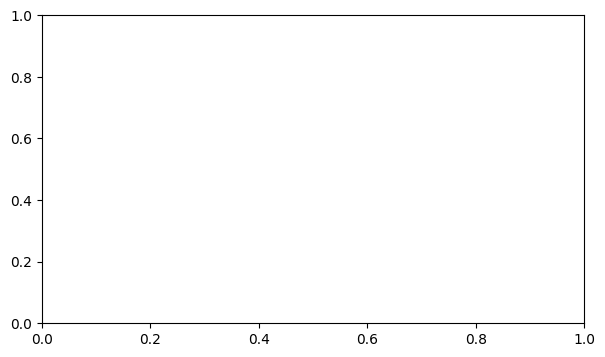

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
box_data  = []
box_labels = []
for res in exp1_results:
    _, rewards = load_tb_scalars(res["log_path"])
    if len(rewards) > 0:
        box_data.append(rewards)
        box_labels.append(res["exp_name"].replace("exp1_", "").replace("_", " "))

if box_data:
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                    boxprops=dict(facecolor="#B3E5FC"), medianprops=dict(color="#0277BD", linewidth=2))
    ax.set_ylabel("Episode Reward", fontsize=11)
    ax.set_title("Experiment 1 — Reward Distribution", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "exp1_boxplot.png"), dpi=150, bbox_inches="tight")
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────

---
## Experiment 4 — DQN vs. Double DQN

**Research question:** Does Double DQN reduce overestimation and improve performance?

Standard DQN suffers from **overestimation bias**: it uses the same network
to both *select* and *evaluate* the best next action, which systematically
inflates Q-value estimates (van Hasselt et al., 2016). Double DQN decouples
selection and evaluation — the online network selects the action, but the
target network evaluates it:

- **DQN target:**         `r + γ · Q_target(s', argmax_a Q_online(s',a))`  (same network selects & evaluates)
- **Double DQN target:**  `r + γ · Q_target(s', argmax_a Q_online(s',a))`  (online selects, target evaluates)

This connects to Q-Learning theory from AI Lecture Slides 14–15.

| Variant     | is_double | All other params |
|-------------|-----------|-----------------|
| DQN         | False     | default |
| Double DQN  | True      | default |

In [ ]:
exp4_configs = [
    ("exp4_dqn",        False),
    ("exp4_double_dqn", True),
]

exp4_results = []
for name, double in exp4_configs:
    res = run_experiment(
        exp_name  = name,
        is_double = double,
    )
    exp4_results.append(res)

print("\nExperiment 4 complete.")

In [ ]:
plot_learning_curves(
    exp4_results,
    title  = "Experiment 4: DQN vs. Double DQN",
    colors = ["#F44336", "#2196F3"],
)

In [ ]:
# We approximate overestimation by comparing the mean Q-value at test time.
# A well-calibrated agent should have Q-values close to actual returns.
fig, ax = plt.subplots(figsize=(9, 4))
colors4 = ["#F44336", "#2196F3"]

for i, res in enumerate(exp4_results):
    steps_q, q_vals = load_tb_scalars(res["log_path"], tag="test/reward")
    steps_r, rewards = load_tb_scalars(res["log_path"], tag="test/reward")
    label = "DQN" if not res["config"]["is_double"] else "Double DQN"
    if len(rewards) > 0:
        ax.plot(steps_r, smooth(rewards, 8), label=label,
                color=colors4[i], linewidth=2)

ax.set_xlabel("Training Steps", fontsize=11)
ax.set_ylabel("Mean Episode Reward", fontsize=11)
ax.set_title("DQN vs. Double DQN — Training Comparison", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "exp4_dqn_vs_double.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df4 = make_summary_table(exp4_results)[
    ["Experiment", "Double DQN", "Best Reward", "Train Time (min)"]
]
print("\nExperiment 4 — Results Summary")
print(df4.to_string(index=False))
df4.to_csv(os.path.join(RESULTS_DIR, "exp4_summary.csv"), index=False)

# ─────────────────────────────────────────────────────────────────────────────

---
## Experiment 2 — Target Network Update Frequency

**Research question:** How often should the target network be updated?

Without a target network, updates to Q(s,a) immediately change the target
`r + γ max Q(s',a')` — a "moving target" that makes training unstable
(AI Lecture Slide 25). By holding a frozen copy (target network) for N steps
before syncing, we stabilise the gradient signal.

**Hypothesis:** Very frequent updates (freq=100) re-introduce instability;
very infrequent updates (freq=1000) slow down learning. A middle value (~500)
should balance stability and speed.

| Variant | Target Update Freq | All other params |
|---------|--------------------|-----------------|
| Fast    | 100 steps          | default |
| Medium  | 500 steps          | default |
| Slow    | 1000 steps         | default |

In [ ]:
exp2_configs = [
    ("exp2_target_100",  100),
    ("exp2_target_500",  500),
    ("exp2_target_1000", 1000),
]

exp2_results = []
for name, freq in exp2_configs:
    res = run_experiment(
        exp_name   = name,
        target_freq = freq,
    )
    exp2_results.append(res)

print("\nExperiment 2 complete.")

In [ ]:
plot_learning_curves(
    exp2_results,
    title  = "Experiment 2: Target Network Update Frequency",
    colors = ["#7E57C2", "#42A5F5", "#26C6DA"],
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Experiment 2 — Stability Analysis", fontsize=13, fontweight="bold")
colors2 = ["#7E57C2", "#42A5F5", "#26C6DA"]

for i, res in enumerate(exp2_results):
    steps, rewards = load_tb_scalars(res["log_path"])
    if len(rewards) < 5:
        continue
    label = res["exp_name"].replace("exp2_target_", "freq=")

    # Rolling variance (stability proxy)
    roll_std = pd.Series(rewards).rolling(window=8, min_periods=1).std().values
    axes[0].plot(steps, smooth(rewards, 8), label=label,
                 color=colors2[i], linewidth=2)
    axes[1].plot(steps, roll_std, label=label, color=colors2[i],
                 linewidth=2, linestyle="--")

axes[0].set_title("Smoothed Reward", fontsize=11)
axes[0].set_xlabel("Steps"); axes[0].set_ylabel("Mean Reward")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title("Rolling Std of Reward (lower = more stable)", fontsize=11)
axes[1].set_xlabel("Steps"); axes[1].set_ylabel("Std Dev")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "exp2_stability.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df2 = make_summary_table(exp2_results)[
    ["Experiment", "Target Update Freq", "Best Reward", "Train Time (min)"]
]
print("\nExperiment 2 — Results Summary")
print(df2.to_string(index=False))
df2.to_csv(os.path.join(RESULTS_DIR, "exp2_summary.csv"), index=False)

# ─────────────────────────────────────────────────────────────────────────────

---
## Experiment 3 — ε-decay Schedule

**Research question:** Which exploration strategy leads to faster and better learning?

ε-greedy exploration is the standard strategy for DQN (AI Lecture Slide 21).
The agent takes a random action with probability ε and the greedy action with
probability 1−ε. The key question is how ε should decay from 1.0 (full
exploration) to a small final value (mostly exploitation) over training.

- **Linear decay:** ε decreases at a constant rate  
- **Exponential decay:** ε decreases quickly at first, then slows  
- **Constant (small) ε:** minimal exploration throughout  

| Variant     | Schedule    | ε start → end |
|-------------|-------------|--------------|
| Linear      | linear      | 1.0 → 0.01  |
| Exponential | exponential | 1.0 → 0.01  |
| Constant    | constant    | 0.05 (fixed) |

In [ ]:
eps_schedule_configs = [
    ("Linear decay",      "linear",      1.0, 0.01, 1_000_000),
    ("Exponential decay", "exponential", 1.0, 0.01, 1_000_000),
    ("Constant (ε=0.05)", "constant",    0.05, 0.05, 1_000_000),
]
plot_epsilon_schedules(eps_schedule_configs, total_steps=MAX_EPOCH * STEP_PER_EPOCH)

In [ ]:
exp3_configs = [
    ("exp3_eps_linear",      "linear",      1.0, 0.01),
    ("exp3_eps_exponential", "exponential", 1.0, 0.01),
    ("exp3_eps_constant",    "constant",    0.05, 0.05),
]

exp3_results = []
for name, sched, e_start, e_final in exp3_configs:
    res = run_experiment(
        exp_name     = name,
        eps_schedule = sched,
        eps_start    = e_start,
        eps_final    = e_final,
    )
    exp3_results.append(res)

print("\nExperiment 3 complete.")

In [ ]:
plot_learning_curves(
    exp3_results,
    title  = "Experiment 3: ε-decay Schedule",
    colors = ["#EC407A", "#AB47BC", "#5C6BC0"],
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Experiment 3 — Early vs. Late Performance", fontsize=13, fontweight="bold")
colors3 = ["#EC407A", "#AB47BC", "#5C6BC0"]

early_rewards = []
late_rewards  = []
labels3       = []

for res in exp3_results:
    _, rewards = load_tb_scalars(res["log_path"])
    if len(rewards) < 4:
        continue
    n = len(rewards)
    early_rewards.append(float(np.mean(rewards[:n//4])))
    late_rewards.append( float(np.mean(rewards[3*n//4:])))
    labels3.append(res["exp_name"].replace("exp3_eps_", ""))

x = np.arange(len(labels3))
w = 0.35
axes[0].bar(x - w/2, early_rewards, w, label="Early (first 25%)",
            color="#FFB74D", alpha=0.85, edgecolor="white")
axes[0].bar(x + w/2, late_rewards,  w, label="Late (last 25%)",
            color="#4FC3F7", alpha=0.85, edgecolor="white")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels3)
axes[0].set_ylabel("Mean Reward"); axes[0].legend()
axes[0].set_title("Early vs. Late Mean Reward"); axes[0].grid(True, alpha=0.3, axis="y")

# Improvement = late - early
improvements = [l - e for l, e in zip(late_rewards, early_rewards)]
axes[1].bar(labels3, improvements, color=colors3[:len(labels3)],
            alpha=0.85, edgecolor="white")
axes[1].set_ylabel("Improvement (late − early reward)")
axes[1].set_title("Total Improvement During Training")
axes[1].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(improvements):
    axes[1].text(i, v + 0.1, f"{v:+.1f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "exp3_early_late.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df3 = make_summary_table(exp3_results)[
    ["Experiment", "ε-Schedule", "Best Reward", "Train Time (min)"]
]
print("\nExperiment 3 — Results Summary")
print(df3.to_string(index=False))
df3.to_csv(os.path.join(RESULTS_DIR, "exp3_summary.csv"), index=False)

# ─────────────────────────────────────────────────────────────────────────────

---
## Overall Summary — All Experiments

In [ ]:
all_results = exp1_results + exp4_results + exp2_results + exp3_results
df_all = make_summary_table(all_results)
print("=" * 80)
print("COMPLETE RESULTS SUMMARY")
print("=" * 80)
print(df_all.to_string(index=False))
df_all.to_csv(os.path.join(RESULTS_DIR, "all_experiments_summary.csv"), index=False)

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

group_names  = ["Exp 1\nBuffer Size", "Exp 2\nDQN Type",
                 "Exp 3\nTarget Freq", "Exp 4\nε-Schedule"]
group_results = [exp1_results, exp4_results, exp2_results, exp3_results]
group_colors  = ["#66BB6A", "#EF5350", "#42A5F5", "#AB47BC"]

best_per_group = []
best_labels    = []
for group in group_results:
    best = max(group, key=lambda r: r["metrics"]["best_reward"])
    best_per_group.append(best["metrics"]["best_reward"])
    best_labels.append(best["exp_name"].replace("_", "\n"))

bars = ax.bar(group_names, best_per_group,
              color=group_colors, alpha=0.85, edgecolor="white", width=0.5)
ax.set_ylabel("Best Mean Reward", fontsize=11)
ax.set_title("Best Result per Experiment Group", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)

for bar, val, lbl in zip(bars, best_per_group, best_labels):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f"{val:.1f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() - 1.5,
            lbl.split("\n")[-1], ha="center", va="top", fontsize=8, color="white")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "overall_best_per_group.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
all_names  = [r["exp_name"].replace("_", " ") for r in all_results]
all_times  = [r["metrics"]["training_time_min"] for r in all_results]
all_colors = (["#66BB6A"] * 3 + ["#EF5350"] * 2 +
              ["#42A5F5"] * 3 + ["#AB47BC"] * 3)

bars = ax.barh(all_names, all_times, color=all_colors[:len(all_names)],
               alpha=0.85, edgecolor="white")
ax.set_xlabel("Training Time (minutes)", fontsize=11)
ax.set_title("Training Time — All Experiments", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")
for bar, val in zip(bars, all_times):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f} min", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "overall_training_time.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("\n📁 All output files saved to:", os.path.abspath(RESULTS_DIR))
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f"   {f}")